# Module 11 — Static fOU Convergence Calibration

Diagnostic-only evaluation of the original static OOS strategy. The question is whether the model-implied 70% convergence probability recorded at entry was empirically calibrated. This module does **not** change the strategy, refit parameters, or optimize thresholds.

Primary comparison:

$$\bar p_{model} = \frac{1}{N}\sum_i P_i(\tau_\mu \le T_i^{70}\mid\mathcal F_{t_i})$$

versus

$$\hat p_{realized}=\frac{1}{N}\sum_i 1\{\tau_{\mu,i}\le T_i^{70}\}.$$

A large negative calibration gap means that the 70% threshold should be described as a **model-implied convergence probability under the fitted fOU assumptions**, not as a realized 70% success probability.

In [7]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtest import run_walk_forward_backtest, backtest_summary
from src.static_convergence_diagnostics import (
    build_trade_calibration_table, calibration_summary,
    exit_reason_summary, horizon_bucket_summary,
)

pd.set_option('display.max_columns', 120)
OUT = Path('data/processed/')
OUT.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Reproduce the original static OOS backtest

In [2]:
train_prices = pd.read_parquet('data/processed/train_prices.parquet')
test_prices = pd.read_parquet('data/processed/test_prices.parquet')
eligible_pairs = pd.read_parquet('data/processed/eligible_pairs.parquet')
cointegrated_pairs = pd.read_parquet('data/processed/cointegrated_pairs.parquet')
rf_data = pd.read_parquet('data/processed/risk_free_rates.parquet')
risk_free_rates = rf_data.iloc[:, 0] if isinstance(rf_data, pd.DataFrame) else pd.Series(rf_data)
risk_free_rates.index = pd.to_datetime(risk_free_rates.index)
risk_free_rates = risk_free_rates.sort_index().astype(float)

results = run_walk_forward_backtest(
    train_prices=train_prices, test_prices=test_prices,
    eligible_pairs=eligible_pairs, cointegrated_pairs=cointegrated_pairs,
    risk_free_rates=risk_free_rates, initial_capital=100000.0,
    entry_z=1.5, target_probability=0.70, memory_window=60,
    max_horizon_days=126, n_paths=5000, ewma_lambda=0.94, seed=42,
)

trades = results['trades'].copy()
equity = results['equity_curve'].copy()
summary = backtest_summary(trades, equity, 100000.0)
display(summary.to_frame('value'))
print('Trade columns:', trades.columns.tolist())

,value
initial_capital,100000.000000
final_equity,132661.064555
total_return,0.326611
max_drawdown,-0.510505
n_trades,254.000000
win_rate,0.488189
average_trade_return,0.077734
median_trade_return,-0.040611
max_concurrent_positions,34.000000


Trade columns: ['pair', 'dependent', 'independent', 'alpha', 'beta', 'entry_date', 'entry_spread', 'entry_z', 'mu', 'direction', 'target_probability', 'convergence_horizon_trading_days', 'probability_at_selected_horizon', 'probability_at_max_horizon', 'required_calendar_days', 'expiry_date', 'option_calendar_dte', 'dependent_option_type', 'independent_option_type', 'dependent_strike', 'independent_strike', 'entry_dependent_spot', 'entry_independent_spot', 'entry_dependent_volatility', 'entry_independent_volatility', 'entry_risk_free_rate', 'entry_dependent_delta', 'entry_independent_delta', 'dependent_contracts', 'independent_contracts', 'target_contract_ratio_ind_over_dep', 'realized_contract_ratio_ind_over_dep', 'relative_hedge_error', 'entry_dependent_option_price', 'entry_independent_option_price', 'entry_premium', 'exit_date', 'exit_reason', 'exit_spread', 'exit_dependent_spot', 'exit_independent_spot', 'exit_dependent_volatility', 'exit_independent_volatility', 'exit_risk_free_ra

## 2. Build trade-level calibration table

In [3]:
cal = build_trade_calibration_table(trades, test_prices.index)
cal.to_parquet(OUT / 'trade_calibration.parquet', index=False)

cols = [
    'pair','entry_date','exit_date','exit_reason',
    'convergence_horizon_trading_days','probability_at_selected_horizon',
    'probability_at_max_horizon','observed_trading_days_to_exit',
    'realized_convergence','realized_within_selected_horizon',
    'selected_horizon_assessable','pnl','trade_return'
]
display(cal[cols].head(20))

,pair,entry_date,exit_date,exit_reason,convergence_horizon_trading_days,probability_at_selected_horizon,probability_at_max_horizon,observed_trading_days_to_exit,realized_convergence,realized_within_selected_horizon,selected_horizon_assessable,pnl,trade_return
0,PNR-NWSA,2022-12-28,2023-02-01,convergence,97,0.7020,0.8076,23,1,1,True,810.085158,1.117492
1,DOV-CDW,2023-01-19,2023-02-01,convergence,87,0.7012,0.8450,9,1,1,True,1366.536296,0.739933
2,EMR-TEL,2022-12-28,2023-02-08,convergence,121,0.7048,0.7272,28,1,1,True,2165.819829,1.167871
3,IFF-SWK,2023-01-10,2023-02-09,convergence,79,0.7028,0.8768,21,1,1,True,4856.411864,2.167896
4,MCO-ZTS,2023-01-18,2023-02-15,convergence,70,0.7000,0.9058,20,1,1,True,469.711339,0.143518
5,MLM-VMC,2023-02-09,2023-03-09,convergence,45,0.7052,0.9830,19,1,1,True,1462.426728,0.404399
6,SHW-HD,2022-12-28,2023-03-27,expiry,60,0.7058,0.9596,60,0,0,True,196.984221,0.071240
7,URI-MS,2023-01-06,2023-03-27,expiry,54,0.7038,0.9560,54,0,0,True,-3038.399949,-0.905439
8,WMT-SPGI,2022-12-28,2023-04-20,expiry,78,0.7012,0.8802,77,0,0,True,-2217.825388,-0.499092
9,SHW-DHI,2022-12-28,2023-04-26,expiry,82,0.7006,0.8826,81,0,0,True,-3331.269139,-1.000000


## 3. Headline calibration test

In [4]:
headline = calibration_summary(cal)
display(headline.to_frame('value'))
headline.to_frame('value').to_csv(OUT / 'calibration_summary.csv')

model_p = headline['mean_model_probability_selected_horizon']
realized_p = headline['observed_convergence_within_selected_horizon']
gap = headline['calibration_gap_observed_minus_model']
print(f'Mean model-implied selected-horizon probability: {model_p:.3%}')
print(f'Realized convergence within selected horizon: {realized_p:.3%}')
print(f'Calibration gap (realized - model): {gap:.3%}')

,value
n_total_trades,254.000000
n_assessable_selected_horizon,232.000000
n_censored_end_of_test,22.000000
mean_model_probability_selected_horizon,0.702873
observed_convergence_rate,0.254310
observed_convergence_within_selected_horizon,0.254310
calibration_gap_observed_minus_model,-0.448563
mean_model_probability_max_horizon,0.857781
expiry_rate,0.745690
brier_score_selected_horizon,0.391048


Mean model-implied selected-horizon probability: 70.287%
Realized convergence within selected horizon: 25.431%
Calibration gap (realized - model): -44.856%


### Interpretation guardrail

The backtest's entry rule asks whether the fitted fOU model assigns at least 70% probability to convergence within some horizon up to 126 trading days. The test below evaluates whether that model probability corresponds to realized OOS frequencies. A failure of calibration does not mechanically imply zero economic value: option P&L can still be positive through asymmetric payoffs. It does imply that the probability should not be interpreted as an empirically validated success rate.

## 4. Economic outcome conditional on exit mechanism

In [5]:
exit_stats = exit_reason_summary(cal)
display(exit_stats)
exit_stats.to_parquet(OUT / 'exit_reason_summary.parquet', index=False)

,exit_reason,n_trades,total_pnl,mean_trade_return,median_trade_return,win_rate,mean_selected_horizon,mean_observed_days_to_exit
0,expiry,173,-101651.625106,-0.110936,-0.246654,0.352601,87.924855,87.942197
1,convergence,59,161168.476710,0.764757,0.733245,0.983051,79.338983,38.372881
2,end_of_test,22,-26855.787049,-0.281103,-0.198961,0.227273,100.636364,50.500000


## 5. Calibration by selected convergence horizon

In [9]:
horizon_stats = horizon_bucket_summary(cal, n_bins=4)
display(horizon_stats)
horizon_stats_save = horizon_stats.copy()

for col in horizon_stats_save.select_dtypes(include="category").columns:
    horizon_stats_save[col] = horizon_stats_save[col].astype(str)

horizon_stats_save.to_parquet(
    OUT / 'horizon_bucket_calibration.parquet',
    index=False
)

,horizon_bucket,n_trades,mean_horizon,mean_model_probability,observed_within_horizon,observed_eventual_convergence,mean_trade_return,total_pnl,calibration_gap
0,"(41.999, 75.0]",63,63.349206,0.703317,0.349206,0.349206,0.185488,8413.953955,-0.354111
1,"(75.0, 82.0]",54,79.074074,0.702622,0.296296,0.296296,0.173515,55964.700687,-0.406326
2,"(82.0, 95.0]",58,88.931034,0.702593,0.241379,0.241379,0.103362,16217.208343,-0.461214
3,"(95.0, 126.0]",57,113.561404,0.702905,0.122807,0.122807,-0.019681,-21079.011381,-0.580098


## 6. Calibration through time

In [10]:
assessable = cal.loc[cal['selected_horizon_assessable']].copy()
assessable['entry_year'] = pd.to_datetime(assessable['entry_date']).dt.year
annual = assessable.groupby('entry_year').agg(
    n_trades=('pair','size'),
    mean_model_probability=('probability_at_selected_horizon','mean'),
    observed_within_horizon=('realized_within_selected_horizon','mean'),
    eventual_convergence=('realized_convergence','mean'),
    expiry_rate=('exit_reason', lambda x: (x == 'expiry').mean()),
    mean_trade_return=('trade_return','mean'),
    total_pnl=('pnl','sum'),
).reset_index()
annual['calibration_gap'] = annual['observed_within_horizon'] - annual['mean_model_probability']
display(annual)
annual.to_parquet(OUT / 'annual_calibration.parquet', index=False)

,entry_year,n_trades,mean_model_probability,observed_within_horizon,eventual_convergence,expiry_rate,mean_trade_return,total_pnl,calibration_gap
0,2022,9,0.702400,0.333333,0.333333,0.666667,0.068692,-2940.641864,-0.369067
1,2023,95,0.702644,0.231579,0.231579,0.768421,0.222761,44317.702294,-0.471065
2,2024,79,0.703081,0.215190,0.215190,0.784810,0.047289,25139.941574,-0.487891
3,2025,49,0.703069,0.346939,0.346939,0.653061,0.008414,-7000.150401,-0.356131


## 7. Visual diagnostics

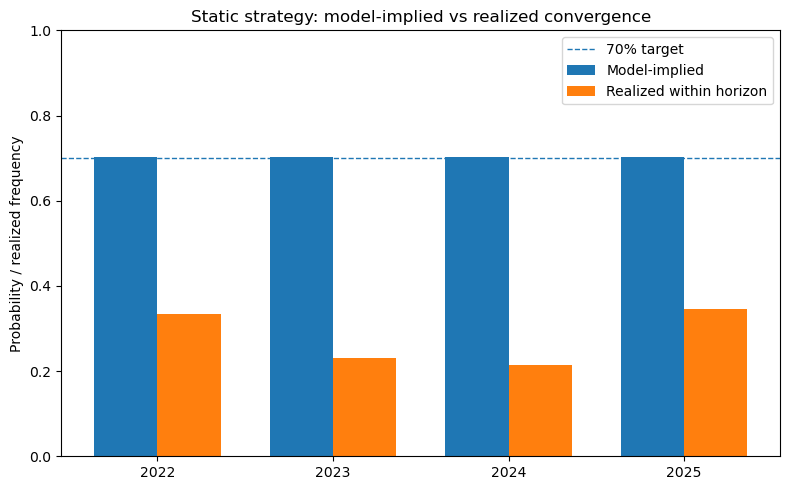

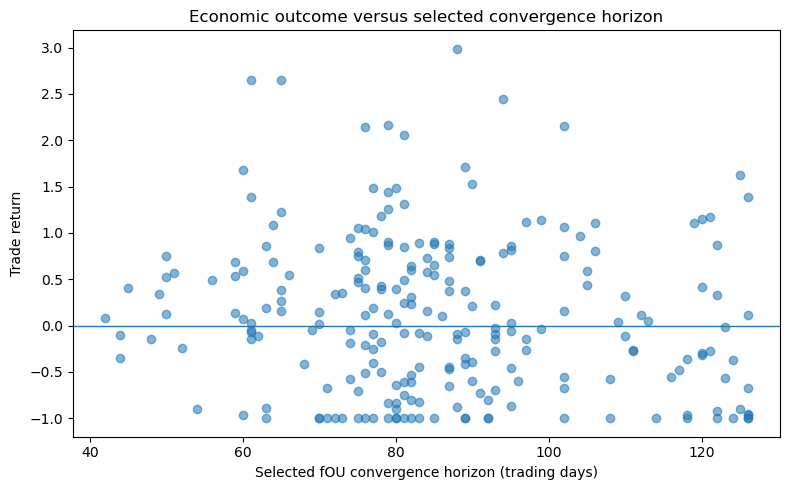

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(annual))
w = 0.36
ax.bar(x - w/2, annual['mean_model_probability'], width=w, label='Model-implied')
ax.bar(x + w/2, annual['observed_within_horizon'], width=w, label='Realized within horizon')
ax.axhline(0.70, linestyle='--', linewidth=1, label='70% target')
ax.set_xticks(x)
ax.set_xticklabels(annual['entry_year'].astype(str))
ax.set_ylim(0, 1)
ax.set_ylabel('Probability / realized frequency')
ax.set_title('Static strategy: model-implied vs realized convergence')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(assessable['convergence_horizon_trading_days'], assessable['trade_return'], alpha=0.55)
ax.axhline(0, linewidth=1)
ax.set_xlabel('Selected fOU convergence horizon (trading days)')
ax.set_ylabel('Trade return')
ax.set_title('Economic outcome versus selected convergence horizon')
plt.tight_layout()
plt.show()

## 8. Convergence versus option P&L asymmetry

In [12]:
economic = assessable.groupby('realized_within_selected_horizon').agg(
    n_trades=('pair','size'),
    total_pnl=('pnl','sum'),
    mean_trade_return=('trade_return','mean'),
    median_trade_return=('trade_return','median'),
    win_rate=('pnl', lambda x: (x > 0).mean()),
).reset_index()
economic['realized_within_selected_horizon'] = economic['realized_within_selected_horizon'].map({0:'No',1:'Yes'})
display(economic)
economic.to_parquet(OUT / 'pnl_by_selected_horizon_success.parquet', index=False)

,realized_within_selected_horizon,n_trades,total_pnl,mean_trade_return,median_trade_return,win_rate
0,No,173,-101651.625106,-0.110936,-0.246654,0.352601
1,Yes,59,161168.476710,0.764757,0.733245,0.983051


## 9. Diagnostic scorecard

In [13]:
gap_abs = abs(float(headline['calibration_gap_observed_minus_model']))
scorecard = pd.DataFrame([
    {
        'question':'Is realized selected-horizon convergence close to the model-implied probability?',
        'result':'YES / ROUGHLY' if gap_abs <= 0.10 else 'NO',
        'evidence':f"model={model_p:.3f}, realized={realized_p:.3f}, gap={gap:.3f}",
    },
    {
        'question':'Does eventual convergence exceed selected-horizon convergence?',
        'result':'YES' if headline['observed_convergence_rate'] > realized_p else 'NO',
        'evidence':f"eventual={headline['observed_convergence_rate']:.3f}, within horizon={realized_p:.3f}",
    },
    {
        'question':'Are expiry trades economically damaging on average?',
        'result':'YES' if float(exit_stats.loc[exit_stats['exit_reason']=='expiry','mean_trade_return'].iloc[0]) < 0 else 'NO',
        'evidence':f"expiry mean return={float(exit_stats.loc[exit_stats['exit_reason']=='expiry','mean_trade_return'].iloc[0]):.3f}",
    },
])
display(scorecard)
scorecard.to_csv(OUT / 'diagnostic_scorecard.csv', index=False)
print('Outputs saved to:', OUT)

,question,result,evidence
0,Is realized selected-horizon convergence close...,NO,"model=0.703, realized=0.254, gap=-0.449"
1,Does eventual convergence exceed selected-hori...,NO,"eventual=0.254, within horizon=0.254"
2,Are expiry trades economically damaging on ave...,YES,expiry mean return=-0.111


Outputs saved to: data\processed


## Thesis interpretation

Use this module as a calibration diagnostic, not as a new selection rule. If realized convergence is materially below the model-implied probability, the appropriate conclusion is that the fOU Monte Carlo probability is conditional on the fitted model and is not empirically calibrated OOS. Do not tune the 70% threshold on the same OOS sample in response.

If the static strategy is materially better calibrated than the rolling extension, that supports the conclusion that frequent re-estimation damaged forecast reliability. If the static strategy is also badly miscalibrated, then the thesis should distinguish model-implied convergence from realized convergence and explain profitability through the full option-payoff distribution rather than the probability threshold alone.